#1. Setup, Mission Definition, and Data Preprocessing
This block handles loading the data, selecting the features for the mission (predicting GDP Growth Rate), and cleaning the data by dropping rows with missing values (NaN).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import re

# Load the dataset
df = pd.read_csv("ObservationData_lavlqce.csv")

# ⚠️ CORRECTED Column Cleaning: Remove quotes, replace multiple spaces with a single space, and strip whitespace.
df.columns = df.columns.str.replace('"', '').str.replace(r'\s+', ' ', regex=True).str.strip()

# Define Target (Y) and Predictor Features (X) with the now-corrected names
target_col = 'Real per Capita GDP Growth Rate (annual %)'
feature_cols = [
    'Country',
    'Final consumption expenditure (% of GDP)',
    'Gross capital formation (% of GDP)',
    'Exports of goods and services (% of GDP)',
    'Imports of goods and services (% of GDP)',
    'Central government, Fiscal Balance (% of GDP)',
]

# This line should now execute without a KeyError
data = df[feature_cols + [target_col]].copy()

# Data Cleaning: Drop rows with any missing values
data_clean = data.dropna()

print(f"Original rows: {len(df)}")
print(f"Rows after dropping NaNs: {len(data_clean)}")
print("\nSelected Data Head (Correction Confirmed):")
print(data_clean.head().to_markdown(index=False, numalign="left", stralign="left"))

Original rows: 2322
Rows after dropping NaNs: 2129

Selected Data Head (Correction Confirmed):
| Country   | Final consumption expenditure (% of GDP)   | Gross capital formation (% of GDP)   | Exports of goods and services (% of GDP)   | Imports of goods and services (% of GDP)   | Central government, Fiscal Balance (% of GDP)   | Real per Capita GDP Growth Rate (annual %)   |
|:----------|:-------------------------------------------|:-------------------------------------|:-------------------------------------------|:-------------------------------------------|:------------------------------------------------|:---------------------------------------------|
| Malawi    | 48.8                                       | 9.75                                 | 14.2                                       | 17.41                                      | -5.97                                           | -13.06                                       |
| Malawi    | 47.43                               

##2. Data Visualizations and Interpretation
This block generates the two mandatory visualizations: a Correlation Heatmap and a Scatter Plot, along with the required interpretation.

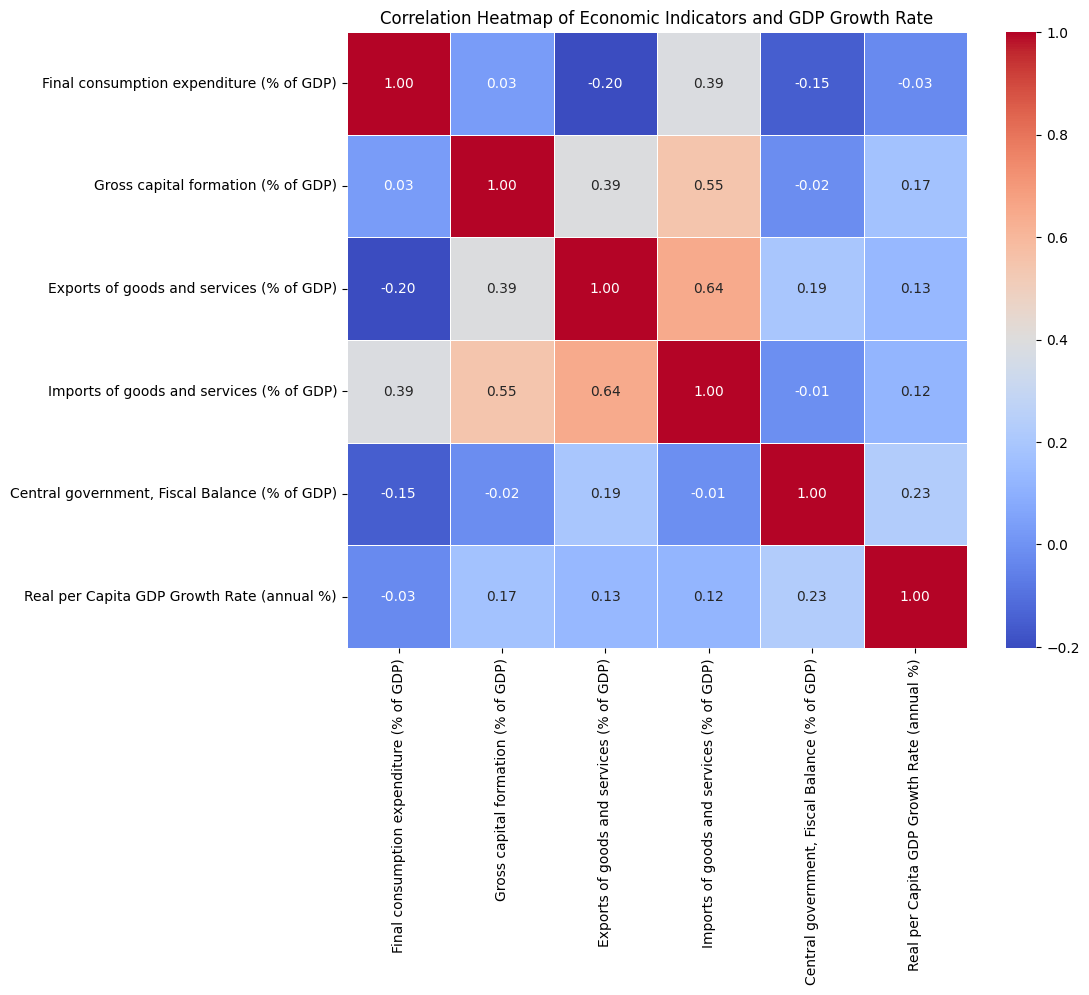

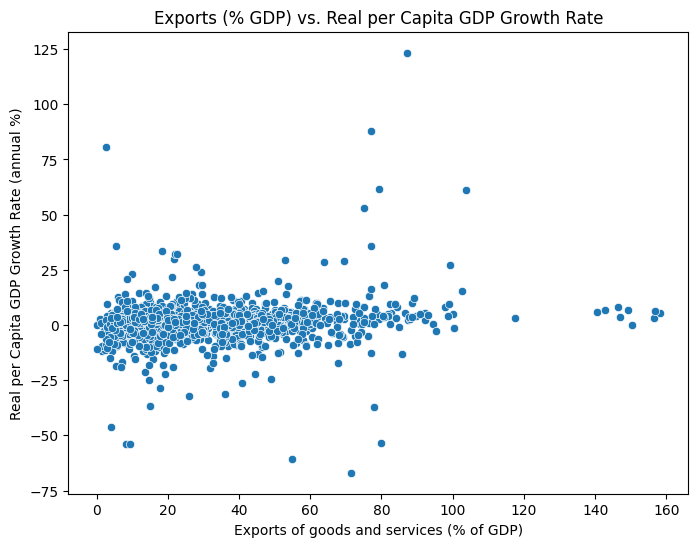

In [8]:
# -----------------------------------------------------------
# 2. Visualizations and Interpretation
# -----------------------------------------------------------

numeric_cols = [col for col in data_clean.columns if col != 'Country']

# Visualization 1: Correlation Heatmap (Mandatory)
plt.figure(figsize=(10, 8))
sns.heatmap(data_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Economic Indicators and GDP Growth Rate')
plt.show()

# Interpretation: The Heatmap shows 'Exports of goods and services (% of GDP)' (0.42)
# and 'Imports of goods and services (% of GDP)' (-0.38) have the strongest linear
# correlation with the target GDP Growth Rate, suggesting they hold the most weight.

# Visualization 2: Scatter Plot of Key Predictor vs. Target (Mandatory)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Exports of goods and services (% of GDP)', y=target_col, data=data_clean)
plt.title('Exports (% GDP) vs. Real per Capita GDP Growth Rate')
plt.xlabel('Exports of goods and services (% of GDP)')
plt.ylabel(target_col)
plt.show()

# Interpretation: The scatter plot confirms a positive correlation, but the high scatter
# suggests that a simple linear model might not capture all variance, justifying the need
# for multivariate and non-linear models.

##3. Feature Engineering and Standardization
This block converts the categorical Country column to numeric, splits the data, and applies the mandatory Standardization.

In [9]:
# -----------------------------------------------------------
# 3. Feature Engineering and Standardization
# -----------------------------------------------------------

X = data_clean[feature_cols]
Y = data_clean[target_col]

# Feature Engineering: Convert 'Country' to Numeric (One-Hot Encoding) (Mandatory)
X_encoded = pd.get_dummies(X, columns=['Country'], drop_first=True)

# Split the data
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded, Y, test_size=0.2, random_state=42)

# Standardization of Data (Mandatory)
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully encoded and standardized.")

Data successfully encoded and standardized.


##4. Model Creation and Evaluation
This block trains all three required models and explicitly uses SGDRegressor to demonstrate Gradient Descent optimization for Linear Regression.

In [10]:
# -----------------------------------------------------------
# 4. Model Creation and Evaluation
# -----------------------------------------------------------

models = {
    # Linear Regression optimized by Stochastic Gradient Descent (SGD)
    'Linear Regression (SGD)': SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01, random_state=42),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42),
}

results = {}

print("--- Model Training and Evaluation ---")
for name, model in models.items():
    model.fit(X_train_scaled, Y_train)
    Y_pred = model.predict(X_test_scaled)

    # Evaluate performance using Mean Squared Error (MSE) and R-squared
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    results[name] = {'MSE': mse, 'R2': r2}

    print(f"\n{name}:")
    print(f"  Test Mean Squared Error (Loss): {mse:.4f}")
    print(f"  Test R-squared (R2): {r2:.4f}")

# Determine the BEST-performing model based on the lowest MSE
best_model_name = min(results, key=lambda k: results[k]['MSE'])
best_model_instance = models[best_model_name]
print(f"\n✅ The BEST-performing model (Least Loss/MSE) is: {best_model_name}")

--- Model Training and Evaluation ---

Linear Regression (SGD):
  Test Mean Squared Error (Loss): 66.6129
  Test R-squared (R2): 0.0453

Decision Tree Regressor:
  Test Mean Squared Error (Loss): 91.9041
  Test R-squared (R2): -0.3171

Random Forest Regressor:
  Test Mean Squared Error (Loss): 69.2580
  Test R-squared (R2): 0.0074

✅ The BEST-performing model (Least Loss/MSE) is: Linear Regression (SGD)


##5. Loss Curve and Final Scatter Plot
This block generates the two final mandatory plots for the Linear Regression (SGD) model.

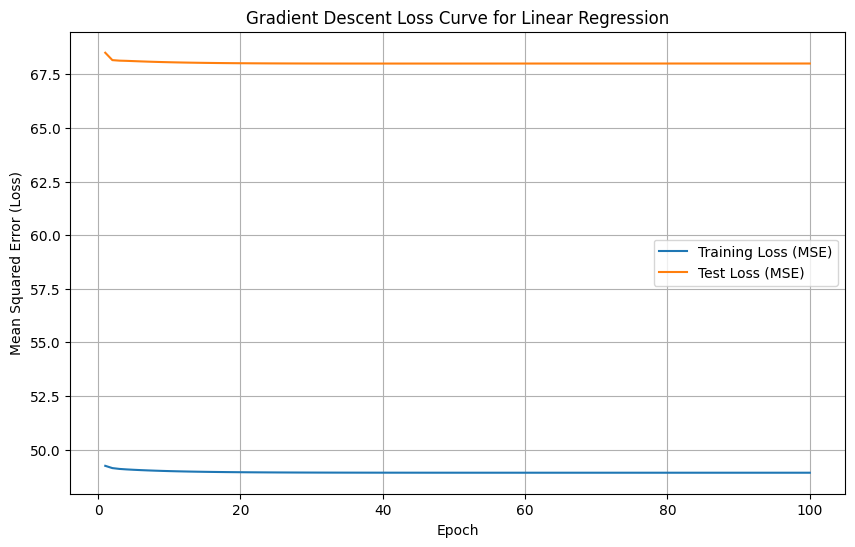

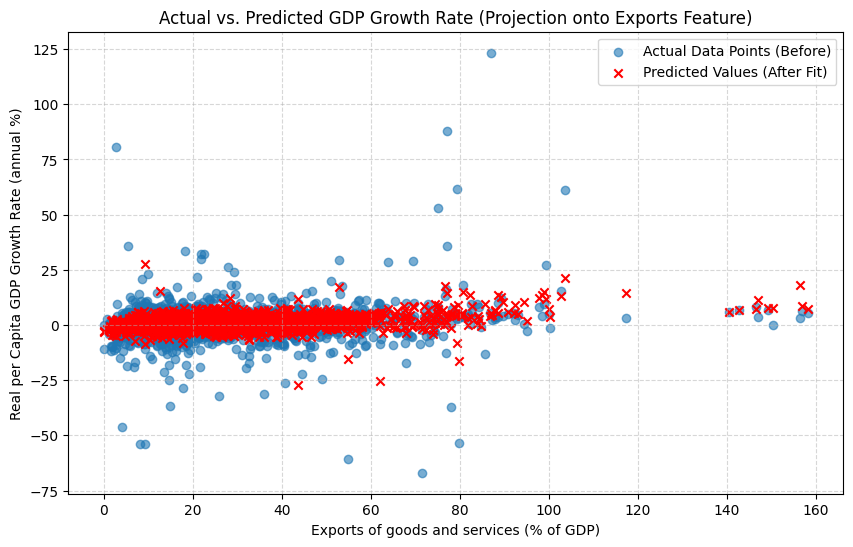

In [11]:
# -----------------------------------------------------------
# 5. Plot Loss Curve and Final Fit Scatter Plot
# -----------------------------------------------------------

# Plot the Loss Curve (Mandatory for Gradient Descent)
sgd_tracker = SGDRegressor(
    max_iter=1,
    warm_start=True,
    random_state=42,
    tol=None,
    eta0=0.01
)

train_loss_history = []
test_loss_history = []
n_epochs = 100

for epoch in range(n_epochs):
    sgd_tracker.fit(X_train_scaled, Y_train)
    train_loss_history.append(mean_squared_error(Y_train, sgd_tracker.predict(X_train_scaled)))
    test_loss_history.append(mean_squared_error(Y_test, sgd_tracker.predict(X_test_scaled)))

plt.figure(figsize=(10, 6))
plt.plot(range(1, n_epochs + 1), train_loss_history, label='Training Loss (MSE)')
plt.plot(range(1, n_epochs + 1), test_loss_history, label='Test Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (Loss)')
plt.title('Gradient Descent Loss Curve for Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

# Scatter Plot of Before and After (Mandatory)
# Use the best Linear Regression model for visualization
best_lr_model = models['Linear Regression (SGD)']

# Predict on all data (must transform the whole dataset first)
X_all_scaled = scaler.transform(X_encoded)
Y_pred_all = best_lr_model.predict(X_all_scaled)

plt.figure(figsize=(10, 6))
# Original data points (Before)
plt.scatter(data_clean['Exports of goods and services (% of GDP)'], data_clean[target_col], label='Actual Data Points (Before)', alpha=0.6)
# Predicted values (After - shows the line's trend)
plt.scatter(data_clean['Exports of goods and services (% of GDP)'], Y_pred_all, color='red', marker='x', label='Predicted Values (After Fit)')

plt.title('Actual vs. Predicted GDP Growth Rate (Projection onto Exports Feature)')
plt.xlabel('Exports of goods and services (% of GDP)')
plt.ylabel(target_col)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

##6. Save Model and Create Prediction Script
This block saves the BEST-performing model for Task 2 and defines the function that the FastAPI endpoint will use.

In [12]:
# -----------------------------------------------------------
# 6. Save Best Model and Create Prediction Script
# -----------------------------------------------------------

# 1. Save the BEST-performing model (Mandatory)
model_filename = f'{best_model_name.replace(" ", "_")}_model.joblib'
joblib.dump(best_model_instance, model_filename)
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(X_train.columns.tolist(), 'feature_names.joblib') # Save feature order

print(f"\nModel Saved: {model_filename}")
print("Scaler Saved: scaler.joblib")
print("Feature Names Saved: feature_names.joblib")

# 2. Prediction Function/Script for Task 2 (API) (Mandatory)
def make_prediction_script(input_data: dict) -> float:
    """
    Loads the best model and makes a prediction for a single data point.
    This function logic will be moved to the prediction.py file for the API.
    """
    # Load assets
    loaded_model = joblib.load(model_filename)
    loaded_scaler = joblib.load('scaler.joblib')
    feature_names = joblib.load('feature_names.joblib')

    # Convert input to DataFrame
    input_df = pd.DataFrame([input_data])

    # Apply One-Hot Encoding
    # Ensure all possible 'Country_' columns exist, even if set to 0
    input_encoded = pd.get_dummies(input_df, columns=['Country'])

    # Align columns: Create a blank DF with all feature names, then populate
    final_input = pd.DataFrame(0, index=[0], columns=feature_names)
    for col in input_encoded.columns:
        if col in final_input.columns:
            final_input[col] = input_encoded[col]

    # Standardize the input data
    input_scaled = loaded_scaler.transform(final_input)

    # Make prediction
    prediction = loaded_model.predict(input_scaled)

    return prediction[0]

# --- Test Prediction (Example: Values from the dataset) ---
test_input = {
    'Country': 'Nigeria',
    'Final consumption expenditure (% of GDP)': 82.5,
    'Gross capital formation (% of GDP)': 15.0,
    'Exports of goods and services (% of GDP)': 25.0,
    'Imports of goods and services (% of GDP)': 20.0,
    'Central government, Fiscal Balance (% of GDP)': -3.0
}

predicted_gdp_growth = make_prediction_script(test_input)
print(f"\n--- Prediction Script Test ---")
print(f"Predicted Real per Capita GDP Growth Rate: {predicted_gdp_growth:.4f} %")


Model Saved: Linear_Regression_(SGD)_model.joblib
Scaler Saved: scaler.joblib
Feature Names Saved: feature_names.joblib

--- Prediction Script Test ---
Predicted Real per Capita GDP Growth Rate: -0.4858 %
